In [2]:
import numpy as np
import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib as m
from matplotlib.pyplot import figure

import statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from math import sqrt
import sklearn
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

In [3]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

sklearn    : 1.5.1
pandas     : 2.2.2
matplotlib : 3.9.2
numpy      : 1.26.4
statsmodels: 0.14.2



In [4]:
dados_treino = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Análise e Previsão de Séries Temporais/Dados/dataset_treino.csv")
dados_teste = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Análise e Previsão de Séries Temporais/Dados/dataset_teste.csv")

In [5]:
dados_treino['data'] = pd.to_datetime(dados_treino.data, format = '%d-%m-%Y %H:%M')
dados_teste['data'] = pd.to_datetime(dados_teste.data, format = '%d-%m-%Y %H:%M')

In [6]:
dados_treino.index = dados_treino['data']
dados_teste.index = dados_teste['data']

In [7]:
dados_treino.drop('id', axis=1, inplace=True)
dados_treino.drop('data', axis=1, inplace=True)

In [8]:
df_treino = dados_treino.iloc[0:16057]
df_valid = dados_treino.iloc[16057:]

In [9]:
df_treino.shape

(16057, 1)

In [10]:
df_valid.shape

(2231, 1)

In [11]:
df_treino_log = np.log(df_treino['consumo_energia'])

In [12]:
modelo_AR = ARIMA(df_treino_log, order= (2,1,0), freq= 'H')

In [13]:
modelo_v3 = modelo_AR.fit()

In [14]:
dados_reais = df_treino_log
previsoes_v3 = modelo_v3.fittedvalues

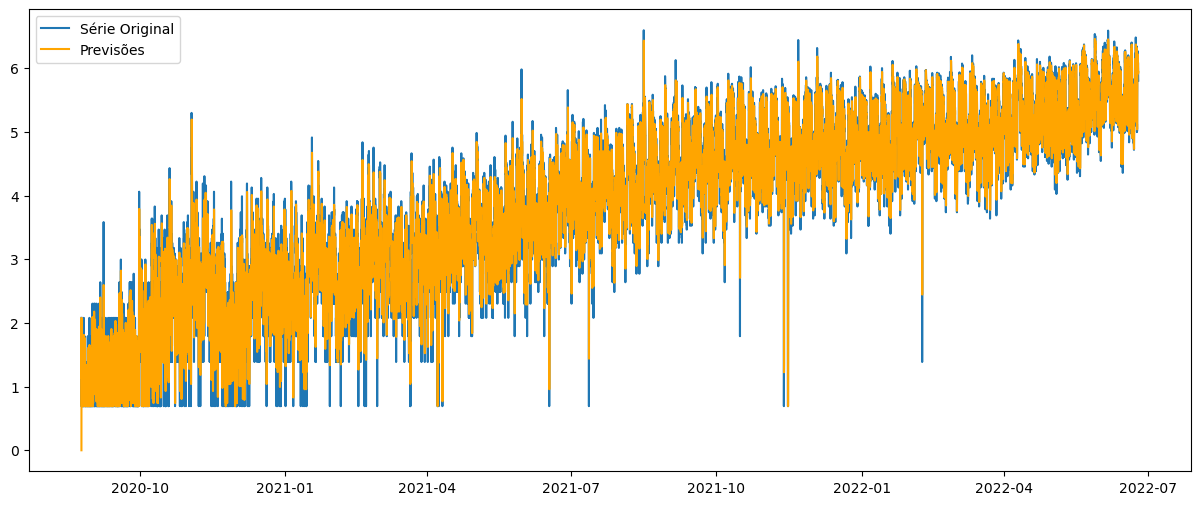

In [15]:
figure(figsize = (15, 6))
plt.plot(dados_reais, label = 'Série Original')
plt.plot(previsoes_v3, color = 'orange', label = 'Previsões')
plt.legend(loc = 'best')
plt.show()

In [16]:
modelo_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        consumo_energia   No. Observations:                16057
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -8119.356
Date:                Tue, 17 Jun 2025   AIC                          16244.711
Time:                        16:28:14   BIC                          16267.763
Sample:                    08-25-2020   HQIC                         16252.334
                         - 06-25-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3419      0.005    -68.096      0.000      -0.352      -0.332
ar.L2         -0.0695      0.006    -11.737      0.000      -0.081      -0.058
sigma2         0.1610      0.001    158.760      0.000       0.159       0.163
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             12378.93
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.24   Skew:                            -0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
df_valid_log = np.log(df_valid['consumo_energia'])

In [18]:
df_previsoes_v3 = modelo_v3.forecast(len(df_valid_log), alpha=0.05)

In [19]:
fc_series = pd.Series(df_previsoes_v3, index = df_valid_log.index)

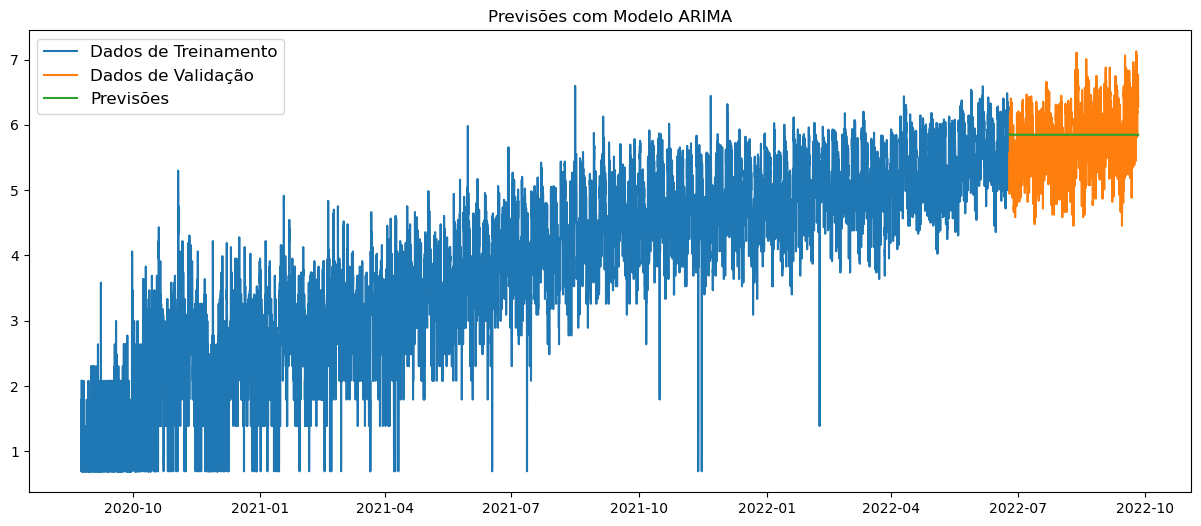

In [20]:
figure(figsize = (15, 6))
plt.plot(df_treino_log, label = 'Dados de Treinamento')
plt.plot(df_valid_log, label = 'Dados de Validação')
plt.plot(fc_series, label = 'Previsões')
plt.title('Previsões com Modelo ARIMA')
plt.legend(loc = 'upper left', fontsize = 12)
plt.show()

In [21]:
fc_series = fc_series.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)

In [22]:
y_true = df_valid_log
y_pred = fc_series

In [23]:
metrica_rmse = sqrt(mean_squared_error(y_true, y_pred))
print(metrica_rmse)

0.4961283297403171


In [24]:
modelo_SARIMAX = SARIMAX(df_treino_log, trend='n', order=(6,1, 0), seasonal_order=(0,1,1,12))

In [25]:
modelo_v4 = modelo_SARIMAX.fit(disp=True)

In [26]:
dados_reais = df_treino_log
previsoes_v4 = modelo_v4.fittedvalues


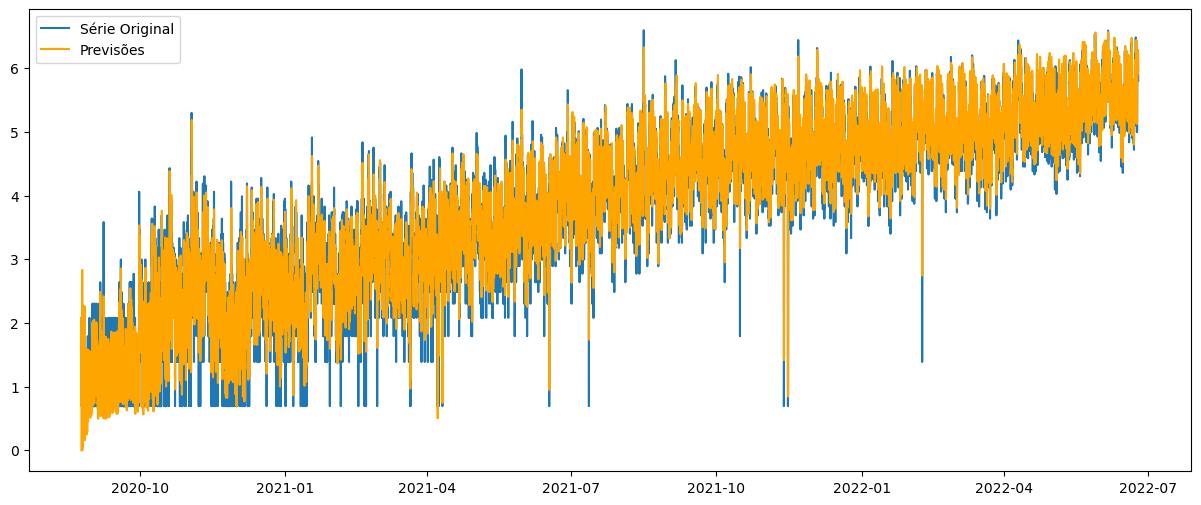

In [27]:
figure(figsize = (15, 6))
plt.plot(dados_reais, label = 'Série Original')
plt.plot(previsoes_v4, color='orange', label='Previsões')
plt.legend(loc='best')
plt.show()

In [28]:
modelo_v4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                      consumo_energia   No. Observations:                16057
Model:             SARIMAX(6, 1, 0)x(0, 1, [1], 12)   Log Likelihood               -7380.094
Date:                              Tue, 17 Jun 2025   AIC                          14776.188
Time:                                      16:29:04   BIC                          14837.652
Sample:                                  08-25-2020   HQIC                         14796.514
                                       - 06-25-2022                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4178      0.005    -85.103      0.000      -0.427      -0.408
ar.L2         -0.1444      0.006    -22.495      0.000      -0.157      -0.132
ar.L3         -0.0446      0.007     -6.651      0.000      -0.058      -0.031
ar.L4         -0.0097      0.006     -1.584      0.113      -0.022       0.002
ar.L5          0.0146      0.006      2.399      0.016       0.003       0.027
ar.L6         -0.0011      0.006     -0.178      0.859      -0.013       0.011
ma.S.L12      -0.9965      0.001   -985.656      0.000      -0.998      -0.995
sigma2         0.1464      0.001    158.159      0.000       0.145       0.148
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             15818.08
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.21   Skew:                            -0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
df_previsoes_v4 = modelo_v4.forecast(len(df_valid_log), alpha=0.05)

In [30]:
df_previsoes_v4.shape

(2231,)

In [31]:
fc_series = pd.Series(df_previsoes_v4, index = df_valid_log.index)

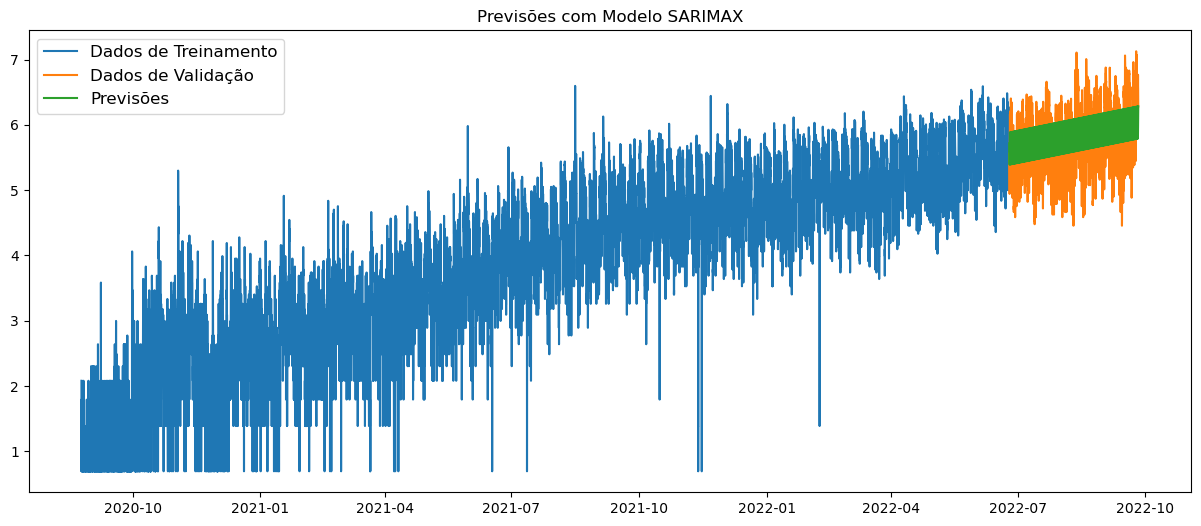

In [32]:
figure(figsize = (15,6))
plt.plot(df_treino_log, label ='Dados de Treinamento')
plt.plot(df_valid_log, label = 'Dados de Validação')
plt.plot(fc_series, label = 'Previsões')
plt.title('Previsões com Modelo SARIMAX')
plt.legend(loc= 'upper left', fontsize = 12)
plt.show()

In [33]:
fc_series = fc_series.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)

In [34]:
y_true = df_valid_log
y_pred = fc_series

In [35]:
metrica_rmse = sqrt(mean_squared_error(y_true, y_pred))
print(metrica_rmse)

0.44385208035772683


In [36]:
previsoes = modelo_v4.predict(start = dados_teste.data[0], end = dados_teste.data[30], dynamic = False)

In [37]:
type(previsoes)

pandas.core.series.Series

In [38]:
previsoes[1:30]

2022-09-26 01:00:00    6.106515
2022-09-26 02:00:00    6.053993
2022-09-26 03:00:00    5.958926
2022-09-26 04:00:00    5.854644
2022-09-26 05:00:00    5.791006
2022-09-26 06:00:00    5.837317
2022-09-26 07:00:00    5.936141
2022-09-26 08:00:00    6.011514
2022-09-26 09:00:00    6.109240
2022-09-26 10:00:00    6.256676
2022-09-26 11:00:00    6.284747
2022-09-26 12:00:00    6.256349
2022-09-26 13:00:00    6.108667
2022-09-26 14:00:00    6.056145
2022-09-26 15:00:00    5.961078
2022-09-26 16:00:00    5.856796
2022-09-26 17:00:00    5.793158
2022-09-26 18:00:00    5.839469
2022-09-26 19:00:00    5.938293
2022-09-26 20:00:00    6.013667
2022-09-26 21:00:00    6.111392
2022-09-26 22:00:00    6.258828
2022-09-26 23:00:00    6.286899
2022-09-27 00:00:00    6.258501
2022-09-27 01:00:00    6.110819
2022-09-27 02:00:00    6.058297
2022-09-27 03:00:00    5.963231
2022-09-27 04:00:00    5.858948
2022-09-27 05:00:00    5.795310
Freq: h, Name: predicted_mean, dtype: float64

In [39]:
np.exp(previsoes[1:30])

2022-09-26 01:00:00    448.771963
2022-09-26 02:00:00    425.809822
2022-09-26 03:00:00    387.194156
2022-09-26 04:00:00    348.850539
2022-09-26 05:00:00    327.342018
2022-09-26 06:00:00    342.858215
2022-09-26 07:00:00    378.471627
2022-09-26 08:00:00    408.100907
2022-09-26 09:00:00    449.996487
2022-09-26 10:00:00    521.482430
2022-09-26 11:00:00    536.328532
2022-09-26 12:00:00    521.312022
2022-09-26 13:00:00    449.738863
2022-09-26 14:00:00    426.727249
2022-09-26 15:00:00    388.028383
2022-09-26 16:00:00    349.602153
2022-09-26 17:00:00    328.047291
2022-09-26 18:00:00    343.596919
2022-09-26 19:00:00    379.287061
2022-09-26 20:00:00    408.980179
2022-09-26 21:00:00    450.966024
2022-09-26 22:00:00    522.605987
2022-09-26 23:00:00    537.484076
2022-09-27 00:00:00    522.435212
2022-09-27 01:00:00    450.707845
2022-09-27 02:00:00    427.646652
2022-09-27 03:00:00    388.864408
2022-09-27 04:00:00    350.355387
2022-09-27 05:00:00    328.754084
Freq: h, Name: